## CMIP output regridding
This notebook does the following:
- crop CMIP files to EPSG:3413 region of interest (immediately makes the files much more manageable) using function crop_cmip.py
- regrid CMIP output to regular grid using function regrid_cmip.py

Update 6 May 2026: regridding for EN4 moved to Step1 notebook for EN4 processing.  Confirm that your grid set in the header here matches the one defined there, if you have edited either.

### Setup
Note that this implementation assumes you have files stored in time slices.  You will comment/uncomment below and run the subsequent cells again for each slice.  This can certainly be updated in a for-loop or other restructuring for high performance computing.

In [18]:
# region of interest in EPSG:3413 and format [xmin,xmax,ymin,ymax]
roi = [-7.2e5,9.6e5,-3.45e6,-0.57e6]

# linear freezing point parameters
l1 = -5.73e-2
l2 = 8.32e-2
l3 = -7.61e-4

# regular grid
hres = 40e3
vres = 50

# files to process
base_dir = '/Users/eultee/Desktop'
# # historical: 1850-2014
# cmipTfile = base_dir + '/thetao_Omon_CESM2-WACCM_historical_r1i1p1f1_gn_185001-201412.nc'
# cmipSfile = base_dir + '/so_Omon_CESM2-WACCM_historical_r1i1p1f1_gn_185001-201412.nc'

# # projection: 2015-2100
# cmipTfile = base_dir + '/ssp585/thetao_Omon_CESM2-WACCM_ssp585_r1i1p1f1_gn_201501-210012.nc'
# cmipSfile = base_dir + '/ssp585/so_Omon_CESM2-WACCM_ssp585_r1i1p1f1_gn_201501-210012.nc'

# # 2101-2150
# cmipTfile = base_dir + '/ssp585/thetao_Omon_CESM2-WACCM_ssp585_r1i1p1f1_gn_210101-215012.nc'
# cmipSfile = base_dir + '/ssp585/so_Omon_CESM2-WACCM_ssp585_r1i1p1f1_gn_210101-215012.nc'

# # 2151-2200
# cmipTfile = base_dir + '/ssp585/thetao_Omon_CESM2-WACCM_ssp585_r1i1p1f1_gn_215101-220012.nc'
# cmipSfile = base_dir + '/ssp585/so_Omon_CESM2-WACCM_ssp585_r1i1p1f1_gn_215101-220012.nc'

# # 2201-2250
# cmipTfile = base_dir + '/ssp585/thetao_Omon_CESM2-WACCM_ssp585_r1i1p1f1_gn_220101-225012.nc'
# cmipSfile = base_dir + '/ssp585/so_Omon_CESM2-WACCM_ssp585_r1i1p1f1_gn_220101-225012.nc'

# 2251-2299
cmipTfile = base_dir + '/ssp585/thetao_Omon_CESM2-WACCM_ssp585_r1i1p1f1_gn_225101-229912.nc'
cmipSfile = base_dir + '/ssp585/so_Omon_CESM2-WACCM_ssp585_r1i1p1f1_gn_225101-229912.nc'

### Imports

In [2]:
import numpy as np
import sys
sys.path.insert(0, '../oceanTF/')
from crop_cmip import crop_cmip
from regrid_cmip import regrid_cmip
from regrid_en4 import regrid_en4

### Setup the regular grid

In [3]:
xreg = np.arange(roi[0],roi[1]+hres,hres)
yreg = np.arange(roi[2],roi[3]+hres,hres)
[Xreg,Yreg] = np.meshgrid(xreg,yreg)
zreg = np.arange(0,2000+vres,vres)

### 1. Crop CMIP raw data to region of interest
Takes around 5 mins per 50 years of CMIP output

In [19]:
# number of time slices to process at a time (120 seems about optimal)
n_chunk = 120

# do crop
crop_cmip(cmipTfile,cmipSfile,roi,n_chunk)

/Users/eultee/miniforge3/envs/odata/lib/python3.13/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'thetao' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/eultee/Documents/GitHub/gris-iceocean-process/salinity/../oceanTF/crop_cmip.py:18: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  dsT = xr.open_dataset(cmipTfile)
/Users/eultee/miniforge3/envs/odata/lib/python3.13/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'so' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/eultee/Documents/GitHub/gris-iceocean-process/salinity/../oceanTF/crop_cmi

Writing temperature time slice from 2251-01-15 12:00:00 to 2260-12-15 12:00:00
Writing temperature time slice from 2261-01-15 12:00:00 to 2270-12-15 12:00:00
Writing temperature time slice from 2271-01-15 12:00:00 to 2280-12-15 12:00:00
Writing temperature time slice from 2281-01-15 12:00:00 to 2290-12-15 12:00:00
Writing temperature time slice from 2291-01-15 12:00:00 to 2299-12-15 12:00:00
Writing salinity time slice from 2251-01-15 12:00:00 to 2260-12-15 12:00:00
Writing salinity time slice from 2261-01-15 12:00:00 to 2270-12-15 12:00:00
Writing salinity time slice from 2271-01-15 12:00:00 to 2280-12-15 12:00:00
Writing salinity time slice from 2281-01-15 12:00:00 to 2290-12-15 12:00:00
Writing salinity time slice from 2291-01-15 12:00:00 to 2299-12-15 12:00:00
All time slices written


### 2. Put CMIP salinity on regular grid

Takes around 10 mins per 50 years of CMIP output

In [20]:
# file from previous stage of processing
cmipSfile_cropped = cmipSfile.replace('.nc','_cropped.nc')

# do regrid
regrid_cmip(cmipSfile_cropped,xreg,yreg,zreg, which_variable='so')

/Users/eultee/Documents/GitHub/gris-iceocean-process/salinity/../oceanTF/regrid_cmip.py:20: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_dataset(cmipTFfile_cropped)
100%|███████████████████████████████████████| 588/588 [2:42:01<00:00, 16.53s/it]


Regridding non-TF variable. Did not correct negative values.


### 3a. Illustrate regridding [optional check]
The cells (regridded) and circles (original resolution) should generally agree.

/var/folders/lm/d_79zh011jddr2c41jsw0dvr0000gq/T/ipykernel_12065/1374698092.py:6: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  dsorig = xr.open_dataset(origfile)
/var/folders/lm/d_79zh011jddr2c41jsw0dvr0000gq/T/ipykernel_12065/1374698092.py:13: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  dsgrid = xr.open_dataset(gridfile)


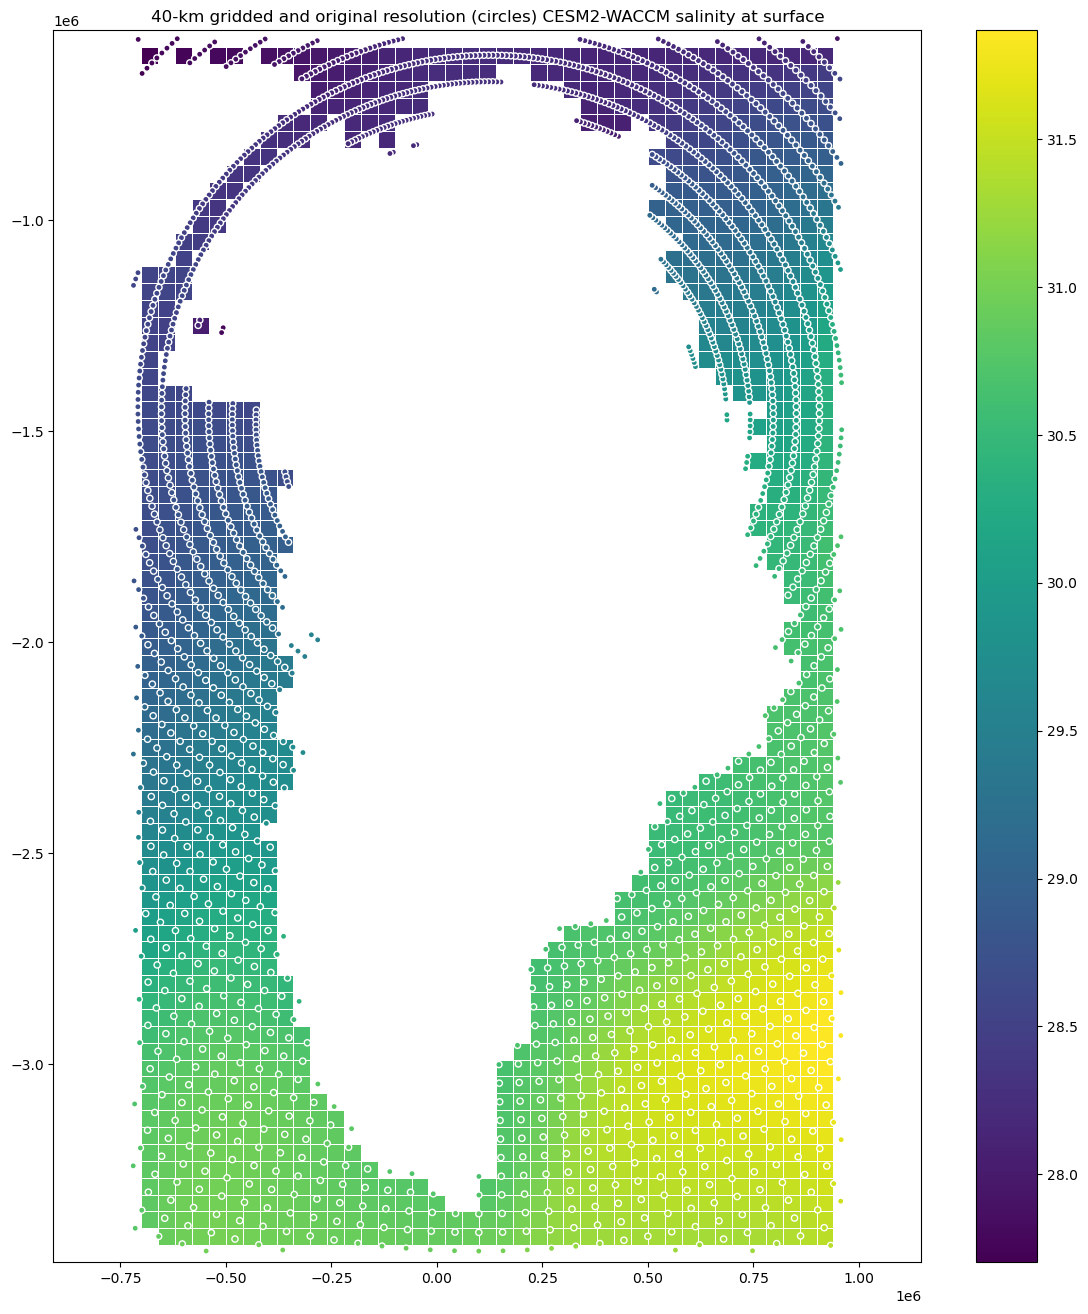

In [21]:
import xarray as xr
import matplotlib.pyplot as plt

# cmip gridding
origfile = '/Users/eultee/Desktop/ssp585/so_Omon_CESM2-WACCM_ssp585_r1i1p1f1_gn_225101-229912_cropped.nc'
dsorig = xr.open_dataset(origfile)
x = dsorig['x'].values
y = dsorig['y'].values
so = dsorig['so'].values

# regular gridding
gridfile = '/Users/eultee/Desktop/ssp585/so_Omon_CESM2-WACCM_ssp585_r1i1p1f1_gn_225101-229912_cropped_regrid.nc'
dsgrid = xr.open_dataset(gridfile)
xgrid = dsgrid['x'].values
ygrid = dsgrid['y'].values
sogrid = dsgrid['so'].values

# plot
fig = plt.figure(figsize=(14,16))
plt.pcolormesh(xgrid,ygrid,sogrid[0,0,:,:],edgecolors='w',linewidth=0.5)
plt.scatter(x,y,c=so[0,0,:],s=20,edgecolors='w')
plt.axis('equal')
plt.title('40-km gridded and original resolution (circles) CESM2-WACCM salinity at surface')
plt.colorbar()
plt.show()